In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_dots_multiple_percentiles(file_dists='dists.csv', 
                                   file_R0='R0.csv', 
                                   file_sigma='sigma.csv',
                                   percentiles=[100, 80, 60, 40, 20, 10],
                                   true_R0=None,
                                   true_sigma=None,
                                   title="R0 vs sigma - Multiple Percentiles",
                                   save_path='../../experimental_data/from_260312/'):
    """
    Create 6 subplots showing R0 vs sigma for different distance percentiles.
    
    Parameters:
    -----------
    file_dists : str
        CSV file with distances (single column)
    file_R0 : str
        CSV file with R0 samples
    file_sigma : str
        CSV file with sigma samples
    percentiles : list
        List of percentiles to plot [100, 80, 60, 40, 20, 10]
    true_R0 : float, optional
        True R0 value to mark on plots
    true_sigma : float, optional
        True sigma value to mark on plots
    title : str
        Overall figure title
    save_path : str
        Directory to save figure
    """
    # Load data
    distances = pd.read_csv(file_dists, header=None).values.ravel()
    data_R0 = pd.read_csv(file_R0, header=None).values.ravel()
    data_sigma = pd.read_csv(file_sigma, header=None).values.ravel()
    
    print(f"Loaded {len(distances)} samples")
    
    # Create figure with 6 subplots (2 rows x 3 columns)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()  # Flatten to 1D array for easy indexing
    
    # Plot for each percentile
    for idx, percentile in enumerate(percentiles):
        ax = axes[idx]
        
        # Calculate threshold
        if percentile == 100:
            # Keep all samples
            selected_indices = np.arange(len(distances))
        else:
            threshold = np.percentile(distances, percentile)
            selected_indices = np.where(distances <= threshold)[0]
        
        n_selected = len(selected_indices)
        print("selected:", n_selected, percentile)
        
        # Select corresponding samples
        selected_R0 = data_R0[selected_indices]
        selected_sigma = data_sigma[selected_indices]
        
        # Scatter plot
        ax.scatter(selected_R0, selected_sigma, alpha=0.5, s=20, c='blue')
        
        # Mark true values if provided
        if true_R0 is not None and true_sigma is not None:
            ax.scatter(true_R0, true_sigma, s=200, c='red', marker='*',
                      edgecolors='black', linewidths=2, label='True value', zorder=5)
            ax.legend(loc='best')
        
        # Labels and title
        ax.set_xlabel('R0', fontsize=11)
        ax.set_ylabel('sigma', fontsize=11)
        ax.set_title(f'{percentile}th percentile\n({n_selected} samples, {n_selected/len(distances)*100:.1f}%)',
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    # Overall title
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save figure
    save_file = f"{save_path}{title.replace(' ', '_').replace('-', '')}.png"
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    print(f"Saved to {save_file}")
    plt.close()


In [3]:
def analyze_distances(
    filepath: str,
    standard_point: tuple,
    weights: tuple = None,
    metric: str = "euclidean",  # "euclidean", "manhattan", "chebyshev", "minkowski", "cosine"
    p: float = 3,               # only used when metric="minkowski"
    output_path: str = "output.csv"
) -> pd.DataFrame:
    """
    Load a headerless CSV with 4 features, apply Min-Max normalization,
    and compute weighted Euclidean distance of each row to a standard point.

    Parameters
    ----------
    filepath       : path to the input CSV file (no header, 4 columns)
    standard_point : tuple of (A0, B0, C0, D0)
    weights        : optional tuple of (wA, wB, wC, wD); if None, equal weights are used.
                     Weights are normalized internally so they sum to 1.
                     Distance = sqrt(wA*(A-A0)² + wB*(B-B0)² + wC*(C-C0)² + wD*(D-D0)²)
    output_path    : path to save the result CSV (default: 'output.csv')

    Returns
    -------
    pd.DataFrame with normalized columns A, B, C, D and a 'distance' column
    """
    # 1. Load
    df = pd.read_csv(filepath, header=None, names=["A", "B", "C", "D"])

    # 2. Min-Max normalization
    col_min = df.min()
    col_max = df.max()
    df_norm = (df - col_min) / (col_max - col_min)

    # 3. Normalize the standard point on the same scale
    standard = np.array(standard_point)
    standard_norm = (standard - col_min.values) / (col_max.values - col_min.values)

    # 4. Resolve weights (normalize so they sum to 1)
    if weights is not None:
        w = np.array(weights, dtype=float)
        if len(w) != 4:
            raise ValueError("weights must have exactly 4 values (wA, wB, wC, wD).")
        if np.any(w < 0):
            raise ValueError("All weights must be non-negative.")
        w = w / w.sum()          # normalize to sum = 1
    else:
        w = np.array([0.25, 0.25, 0.25, 0.25])   # equal weights

    # 5. Weighted Euclidean distance
    diff = (df_norm[["A", "B", "C", "D"]] - standard_norm).values
    if metric == "euclidean":
        dist = np.sqrt((w * diff ** 2).sum(axis=1))

    elif metric == "manhattan":
        dist = (w * np.abs(diff)).sum(axis=1)

    elif metric == "chebyshev":
        dist = (w * np.abs(diff)).max(axis=1)

    elif metric == "minkowski":
        dist = ((w * np.abs(diff) ** p).sum(axis=1)) ** (1 / p)

    elif metric == "cosine":
        dot     = (w * df_norm[["A", "B", "C", "D"]].values * standard_norm).sum(axis=1)
        norm_x  = np.sqrt((w * df_norm[["A", "B", "C", "D"]].values ** 2).sum(axis=1))
        norm_x0 = np.sqrt((w * standard_norm ** 2).sum())
        dist    = 1 - dot / (norm_x * norm_x0)

    else:
        raise ValueError(f"Unknown metric '{metric}'. Choose from: euclidean, manhattan, chebyshev, minkowski, cosine.")

    df_norm["distance"] = dist

    # 6. Save & return
    df_norm[["distance"]].to_csv(output_path, index=False, header=False)
    print(f"Done. Results saved to '{output_path}'.")
    return df_norm

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_dots_from_two_files(
    file_ss='ss.csv',
    file_R0='R0.csv',
    title='Scatter Plot',
    ss_name='npmi',
    save_dir='.'
):
    """
    Plot scatter points using:
    - x = 1st column of file_R0
    - y = 3rd column of file_ss

    Parameters
    ----------
    file_ss : str
        Path to CSV file ss
    file_R0 : str
        Path to CSV file R0
    title : str
        Figure title
    save_dir : str
        Directory to save the figure
    """
    # Load CSV files
    data_ss = pd.read_csv(file_ss, header=None)
    data_R0 = pd.read_csv(file_R0, header=None)

    print(f"Loaded A shape: {data_ss.shape}")
    print(f"Loaded B shape: {data_R0.shape}")

    # Check column counts
    if data_ss.shape[1] < 3:
        raise ValueError(f"file_ss must have at least 3 columns, but got {data_ss.shape[1]}")
    if data_R0.shape[1] < 1:
        raise ValueError(f"file_R0 must have at least 1 column, but got {data_R0.shape[1]}")

    # Check row counts
    if len(data_ss) != len(data_R0):
        raise ValueError(
            f"file_ss and file_R0 must have the same number of rows, "
            f"but got {len(data_ss)} and {len(data_R0)}"
        )

    # Extract columns
    x = data_R0.iloc[:, 0]
    if ss_name=='avg_prev': 
        y = data_ss.iloc[:, 0]
    elif ss_name=='var_prev': 
        y = data_ss.iloc[:, 1]
    elif ss_name=='npmi': 
        y = data_ss.iloc[:, 2]
    elif ss_name=='div_all_isolates':
        y = data_ss.iloc[:, 3]

    # Make save directory if needed
    os.makedirs(save_dir, exist_ok=True)

    # Safe filename
    filename = title.replace(" ", "_") + ".png"
    save_path = os.path.join(save_dir, filename)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y)
    plt.xlabel("R0")
    plt.ylabel(f"Third column of {ss_name}")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    # plt.show()

    print(f"Figure saved to: {save_path}")

Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_avg_prev.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_var_prev.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_npmi.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_div_all_isolates.png


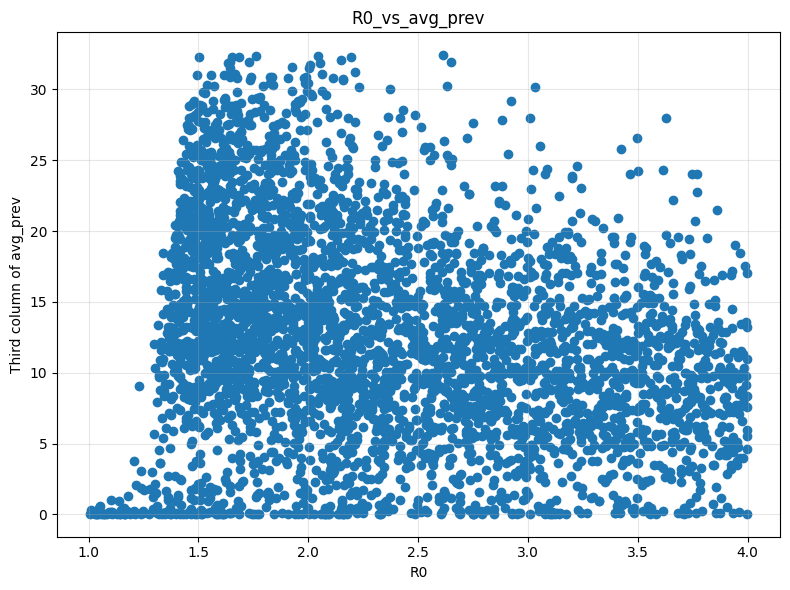

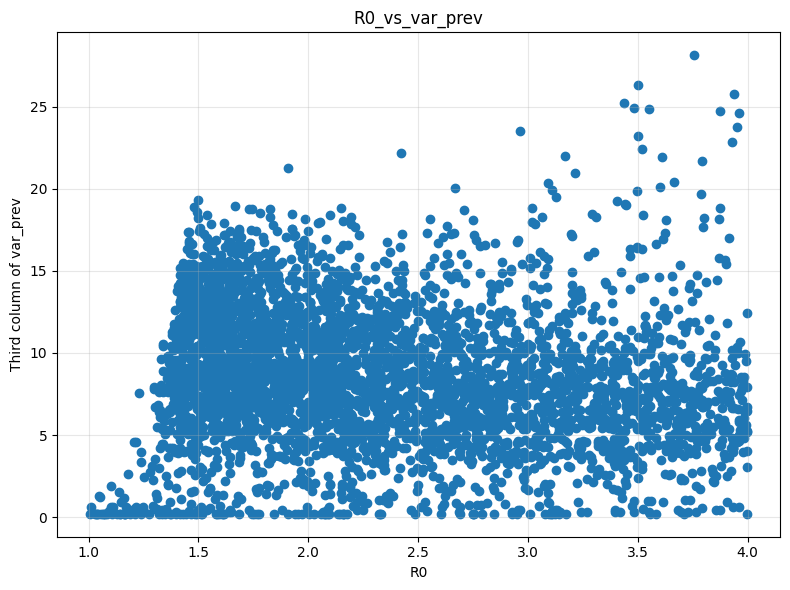

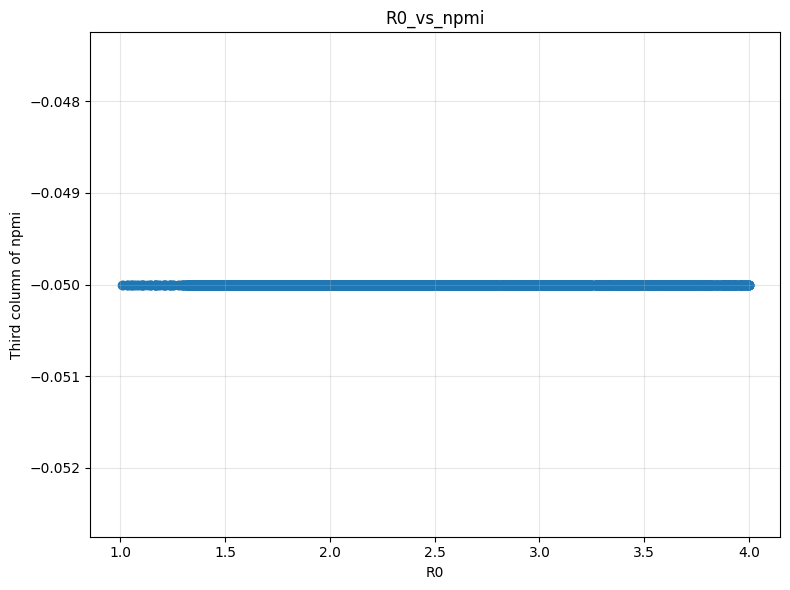

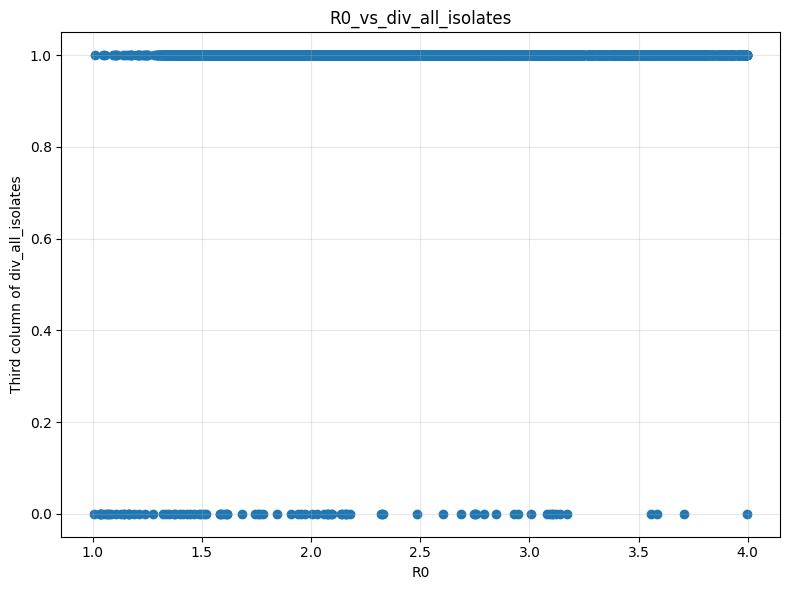

In [5]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R02p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R02p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    title='R0_vs_avg_prev',
    ss_name='avg_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R02p5/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R02p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    title='R0_vs_var_prev',
    ss_name='var_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R02p5/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R02p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    title='R0_vs_npmi',
    ss_name='npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R02p5/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R02p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    title='R0_vs_div_all_isolates',
    ss_name='div_all_isolates',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R02p5/'
)

In [6]:
# for euclidean, manhattan, chebyshev, minkowski, cosine
# 1. Euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R02p5.csv",
        standard_point=(8.39130435, 6.63831256, -0.05, 1.),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R02p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R02p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)

# 2. Manhattan distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R02p5.csv",
        standard_point=(8.39130435, 6.63831256, -0.05, 1.),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="manhattan",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R02p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R02p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-manhattan",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)

# 3. chebyshev
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R02p5.csv",
        standard_point=(8.39130435, 6.63831256, -0.05, 1.),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="chebyshev",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R02p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R02p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-chebyshev",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)

# 4. minkowski
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R02p5.csv",
        standard_point=(8.39130435, 6.63831256, -0.05, 1.),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="minkowski",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R02p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R02p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-minkowski",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)

# 5. cosine
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R02p5.csv",
        standard_point=(8.39130435, 6.63831256, -0.05, 1.),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="cosine",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R02p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R02p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-cosine",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)


# for different wegihts in euclidean
# 1. (0.1, 0.1, 0.7, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R02p5.csv",
        standard_point=(8.39130435, 6.63831256, -0.05, 1.),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R02p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R02p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight1",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)

# 2. (0.7, 0.1, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R02p5.csv",
        standard_point=(8.39130435, 6.63831256, -0.05, 1.),
        weights=(0.7, 0.1, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R02p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R02p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight2",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)

# 3. (0.1, 0.7, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R02p5.csv",
        standard_point=(8.39130435, 6.63831256, -0.05, 1.),
        weights=(0.1, 0.7, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R02p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R02p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight3",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)

# 4. (0.1, 0.1, 0.1, 0.7) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R02p5.csv",
        standard_point=(8.39130435, 6.63831256, -0.05, 1.),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R02p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R02p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight4",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)


# 5. (0.05, 0.05, 0.7, 0.2) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R02p5.csv",
        standard_point=(8.39130435, 6.63831256, -0.05, 1.),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R02p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R02p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R02p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=2.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight5",
    save_path="../../figures/from_260312/ppc/sigma0p6/R02p5/"
)


/var/folders/nz/wbtzvl096gsgl2x7l620cgf4qzjgbz/T/ipykernel_39025/3271564478.py:36: RuntimeWarning: invalid value encountered in divide
  standard_norm = (standard - col_min.values) / (col_max.values - col_min.values)


Done. Results saved to '../../experimental_data/from_260312/dists_R02p5_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 0 80
selected: 0 60
selected: 0 40
selected: 0 20
selected: 0 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_sigma__Multiple_Percentileseuclidean.png
Done. Results saved to '../../experimental_data/from_260312/dists_R02p5_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 0 80
selected: 0 60
selected: 0 40
selected: 0 20
selected: 0 10


/var/folders/nz/wbtzvl096gsgl2x7l620cgf4qzjgbz/T/ipykernel_39025/3271564478.py:36: RuntimeWarning: invalid value encountered in divide
  standard_norm = (standard - col_min.values) / (col_max.values - col_min.values)


Saved to ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_sigma__Multiple_Percentilesmanhattan.png
Done. Results saved to '../../experimental_data/from_260312/dists_R02p5_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 0 80
selected: 0 60
selected: 0 40
selected: 0 20
selected: 0 10


/var/folders/nz/wbtzvl096gsgl2x7l620cgf4qzjgbz/T/ipykernel_39025/3271564478.py:36: RuntimeWarning: invalid value encountered in divide
  standard_norm = (standard - col_min.values) / (col_max.values - col_min.values)


...

Saved to ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_sigma__Multiple_Percentileseuclidean_weight3.png
Done. Results saved to '../../experimental_data/from_260312/dists_R02p5_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 0 80
selected: 0 60
selected: 0 40
selected: 0 20
selected: 0 10


/var/folders/nz/wbtzvl096gsgl2x7l620cgf4qzjgbz/T/ipykernel_39025/3271564478.py:36: RuntimeWarning: invalid value encountered in divide
  standard_norm = (standard - col_min.values) / (col_max.values - col_min.values)


Saved to ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_sigma__Multiple_Percentileseuclidean_weight4.png
Done. Results saved to '../../experimental_data/from_260312/dists_R02p5_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 0 80
selected: 0 60
selected: 0 40
selected: 0 20
selected: 0 10


/var/folders/nz/wbtzvl096gsgl2x7l620cgf4qzjgbz/T/ipykernel_39025/3271564478.py:36: RuntimeWarning: invalid value encountered in divide
  standard_norm = (standard - col_min.values) / (col_max.values - col_min.values)


Saved to ../../figures/from_260312/ppc/sigma0p6/R02p5/R0_vs_sigma__Multiple_Percentileseuclidean_weight5.png


Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R03p0/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R03p0/R0_vs_avg_prev.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R03p0/R0_vs_var_prev.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R03p0/R0_vs_npmi.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R03p0/R0_vs_div_all_isolates.png


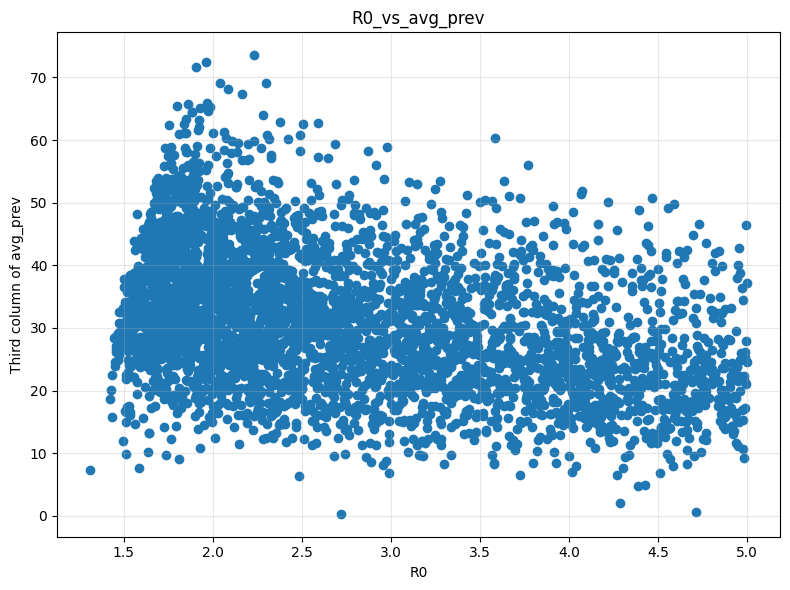

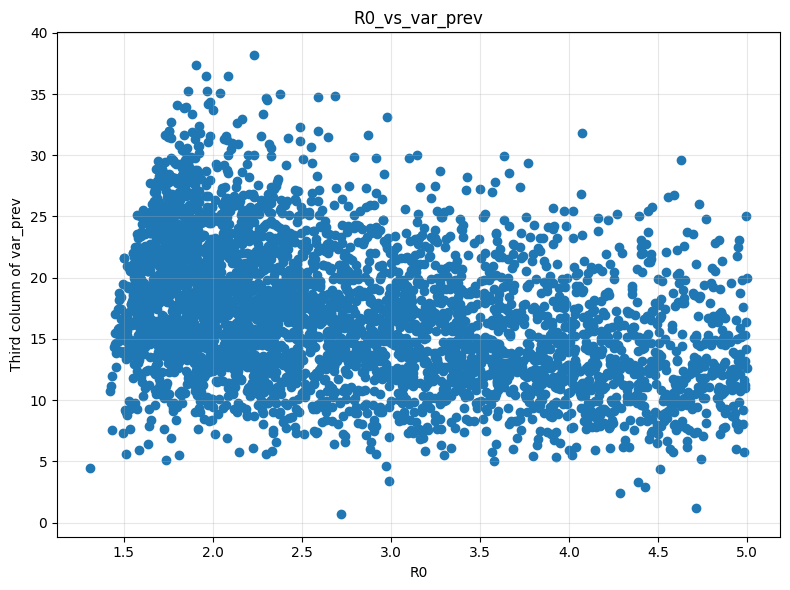

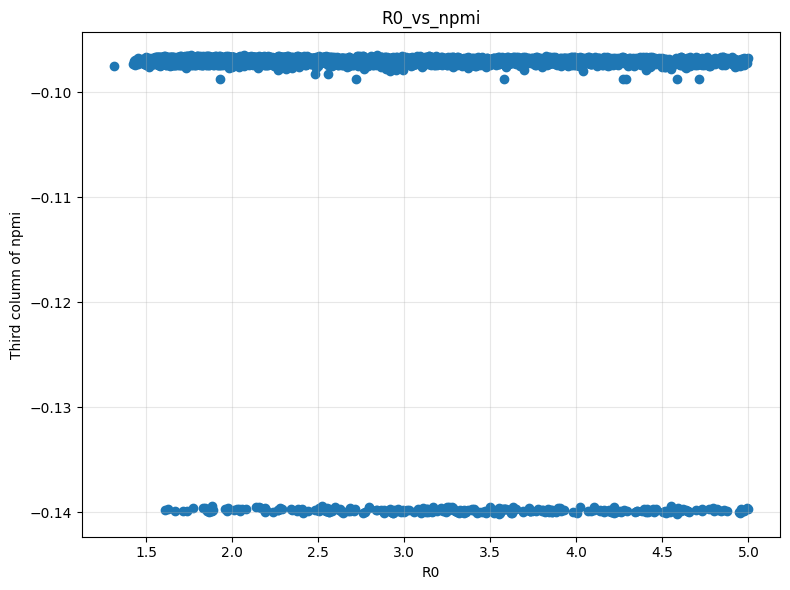

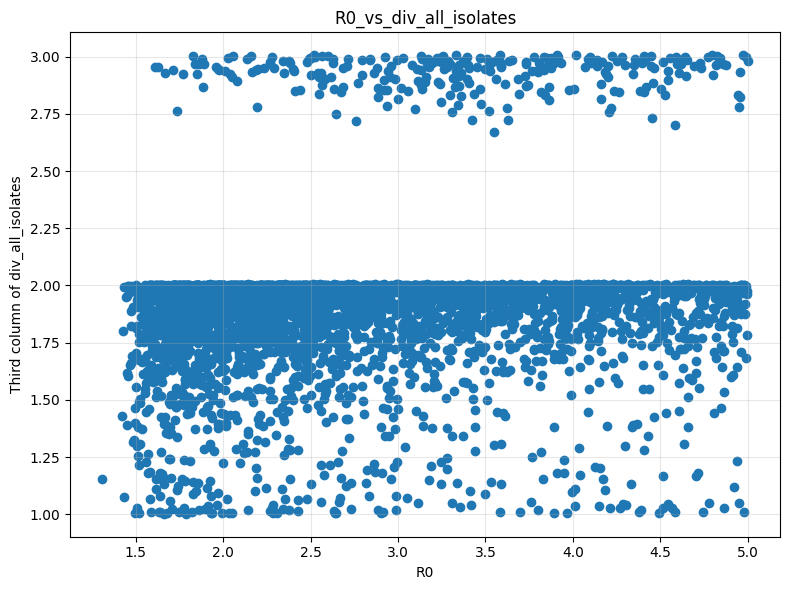

In [7]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R03p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R03p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    title='R0_vs_avg_prev',
    ss_name='avg_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R03p0/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R03p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    title='R0_vs_var_prev',
    ss_name='var_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R03p0/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R03p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    title='R0_vs_npmi',
    ss_name='npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R03p0/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R03p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    title='R0_vs_div_all_isolates',
    ss_name='div_all_isolates',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R03p0/'
)

In [8]:
# for euclidean, manhattan, chebyshev, minkowski, cosine
# 1. Euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p0.csv",
        standard_point=(32.17391304, 18.55863478, -0.09689335,  1.98871199),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)

# 2. Manhattan distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p0.csv",
        standard_point=(32.17391304, 18.55863478, -0.09689335,  1.98871199),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="manhattan",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-manhattan",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)

# 3. chebyshev
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p0.csv",
        standard_point=(32.17391304, 18.55863478, -0.09689335,  1.98871199),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="chebyshev",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-chebyshev",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)

# 4. minkowski
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p0.csv",
        standard_point=(32.17391304, 18.55863478, -0.09689335,  1.98871199),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="minkowski",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-minkowski",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)

# 5. cosine
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p0.csv",
        standard_point=(32.17391304, 18.55863478, -0.09689335,  1.98871199),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="cosine",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-cosine",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)


# for different wegihts in euclidean
# 1. (0.1, 0.1, 0.7, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p0.csv",
        standard_point=(32.17391304, 18.55863478, -0.09689335,  1.98871199),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight1",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)

# 2. (0.7, 0.1, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p0.csv",
        standard_point=(32.17391304, 18.55863478, -0.09689335,  1.98871199),
        weights=(0.7, 0.1, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight2",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)

# 3. (0.1, 0.7, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p0.csv",
        standard_point=(32.17391304, 18.55863478, -0.09689335,  1.98871199),
        weights=(0.1, 0.7, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight3",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)

# 4. (0.1, 0.1, 0.1, 0.7) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p0.csv",
        standard_point=(32.17391304, 18.55863478, -0.09689335,  1.98871199),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight4",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)


# 5. (0.05, 0.05, 0.7, 0.2) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p0.csv",
        standard_point=(32.17391304, 18.55863478, -0.09689335,  1.98871199),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight5",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p0/"
)


Done. Results saved to '../../experimental_data/from_260312/dists_R03p0_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R03p0/R0_vs_sigma__Multiple_Percentileseuclidean.png
Done. Results saved to '../../experimental_data/from_260312/dists_R03p0_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R03p0/R0_vs_sigma__Multiple_Percentilesmanhattan.png
Done. Results saved to '../../experimental_data/from_260312/dists_R03p0_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 3201 80
selected: 2400 60
selected: 1600 40
selected: 803 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R03p0/R0_vs_sigma__Multiple_Percentileschebyshev.png
Done. Results saved to '../../experimental_data/from_260312/dist

Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R03p5/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R03p5/R0_vs_avg_prev.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R03p5/R0_vs_var_prev.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R03p5/R0_vs_npmi.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R03p5/R0_vs_div_all_isolates.png


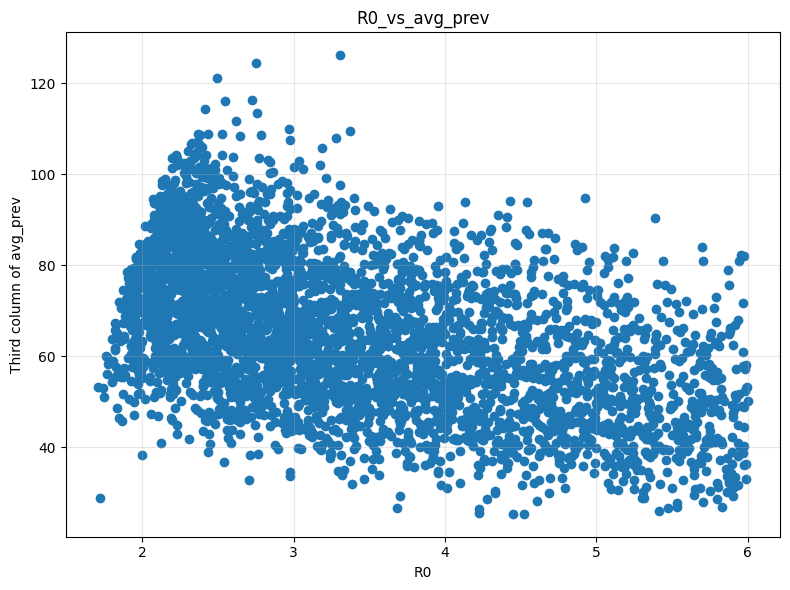

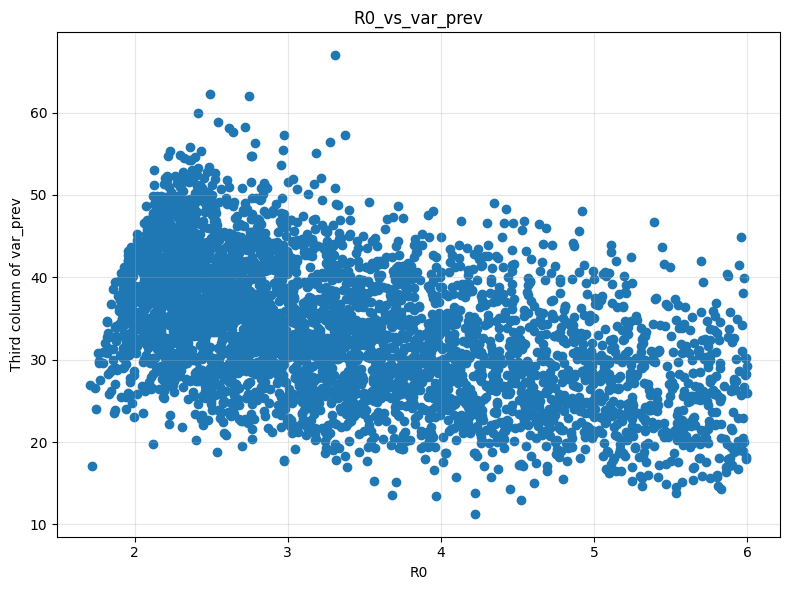

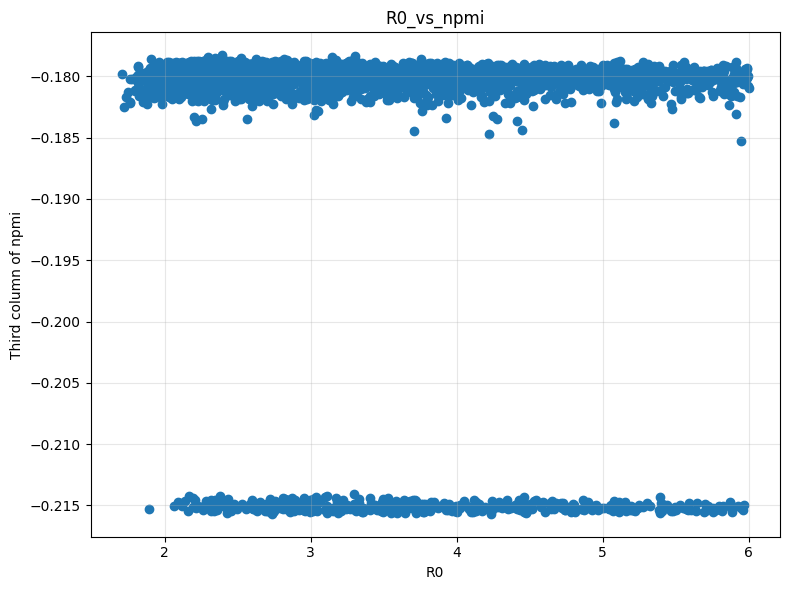

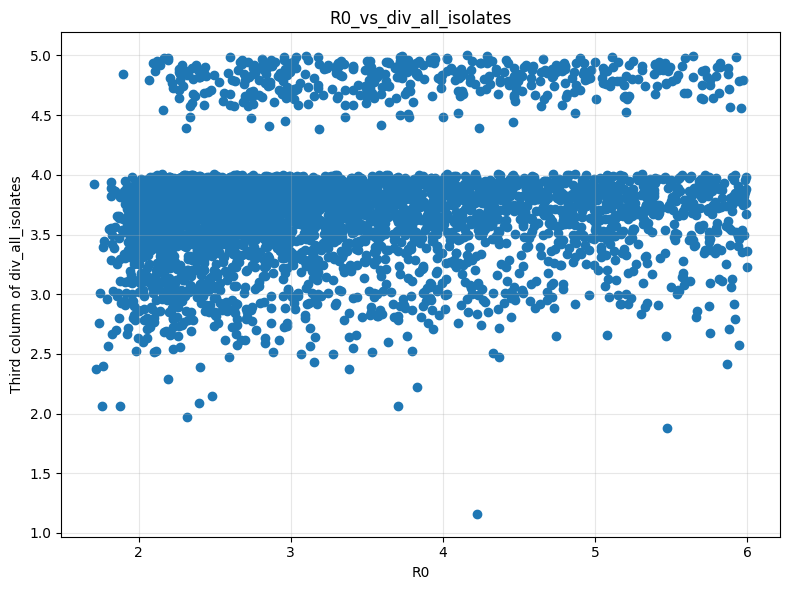

In [9]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R03p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R03p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    title='R0_vs_avg_prev',
    ss_name='avg_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R03p5/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R03p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    title='R0_vs_var_prev',
    ss_name='var_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R03p5/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R03p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    title='R0_vs_npmi',
    ss_name='npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R03p5/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R03p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    title='R0_vs_div_all_isolates',
    ss_name='div_all_isolates',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R03p5/'
)

In [11]:
# for euclidean, manhattan, chebyshev, minkowski, cosine
# 1. Euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p5.csv",
        standard_point=(68.04347826, 35.00841231, -0.17978602, 3.90770282),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)

# 2. Manhattan distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p5.csv",
        standard_point=(68.04347826, 35.00841231, -0.17978602, 3.90770282),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="manhattan",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-manhattan",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)

# 3. chebyshev
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p5.csv",
        standard_point=(68.04347826, 35.00841231, -0.17978602, 3.90770282),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="chebyshev",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-chebyshev",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)

# 4. minkowski
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p5.csv",
        standard_point=(68.04347826, 35.00841231, -0.17978602, 3.90770282),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="minkowski",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-minkowski",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)

# 5. cosine
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p5.csv",
        standard_point=(68.04347826, 35.00841231, -0.17978602, 3.90770282),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="cosine",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-cosine",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)


# for different wegihts in euclidean
# 1. (0.1, 0.1, 0.7, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p5.csv",
        standard_point=(68.04347826, 35.00841231, -0.17978602, 3.90770282),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight1",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)

# 2. (0.7, 0.1, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p5.csv",
        standard_point=(68.04347826, 35.00841231, -0.17978602, 3.90770282),
        weights=(0.7, 0.1, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight2",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)

# 3. (0.1, 0.7, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p5.csv",
        standard_point=(68.04347826, 35.00841231, -0.17978602, 3.90770282),
        weights=(0.1, 0.7, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight3",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)

# 4. (0.1, 0.1, 0.1, 0.7) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p5.csv",
        standard_point=(68.04347826, 35.00841231, -0.17978602, 3.90770282),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight4",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)


# 5. (0.05, 0.05, 0.7, 0.2) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R03p5.csv",
        standard_point=(68.04347826, 35.00841231, -0.17978602, 3.90770282),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R03p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R03p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R03p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R03p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=3.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight5",
    save_path="../../figures/from_260312/ppc/sigma0p6/R03p5/"
)


Done. Results saved to '../../experimental_data/from_260312/dists_R03p5_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R03p5/R0_vs_sigma__Multiple_Percentileseuclidean.png
Done. Results saved to '../../experimental_data/from_260312/dists_R03p5_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R03p5/R0_vs_sigma__Multiple_Percentilesmanhattan.png
Done. Results saved to '../../experimental_data/from_260312/dists_R03p5_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R03p5/R0_vs_sigma__Multiple_Percentileschebyshev.png
Done. Results saved to '../../experimental_data/from_260312/dist

Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R04p0/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R04p0/R0_vs_avg_prev.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R04p0/R0_vs_var_prev.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R04p0/R0_vs_npmi.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)
Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R04p0/R0_vs_div_all_isolates.png


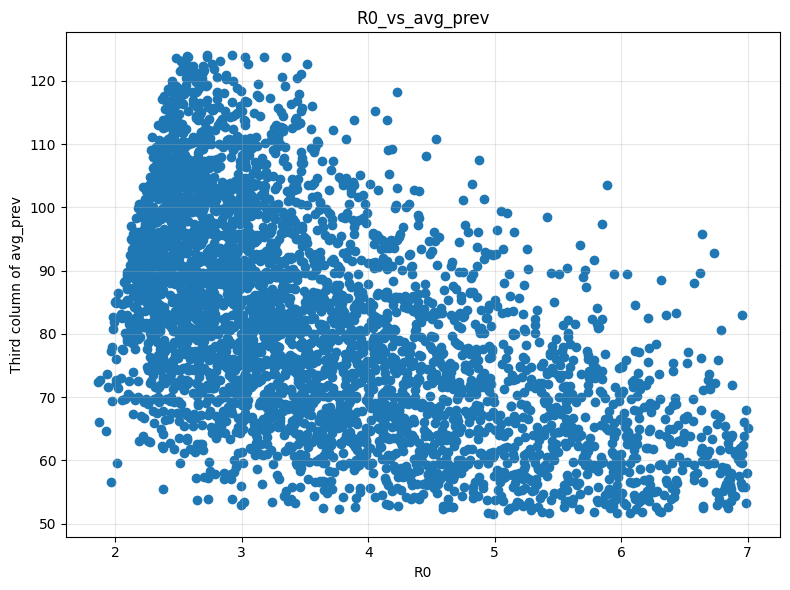

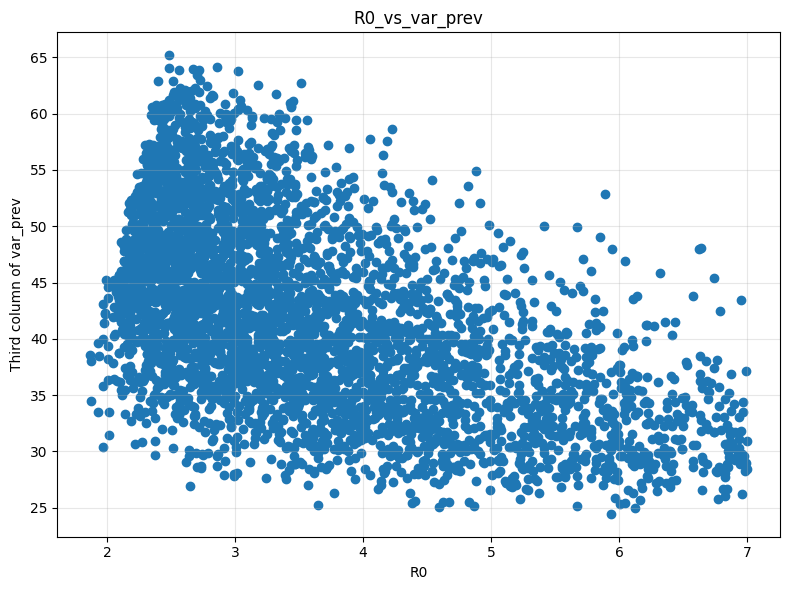

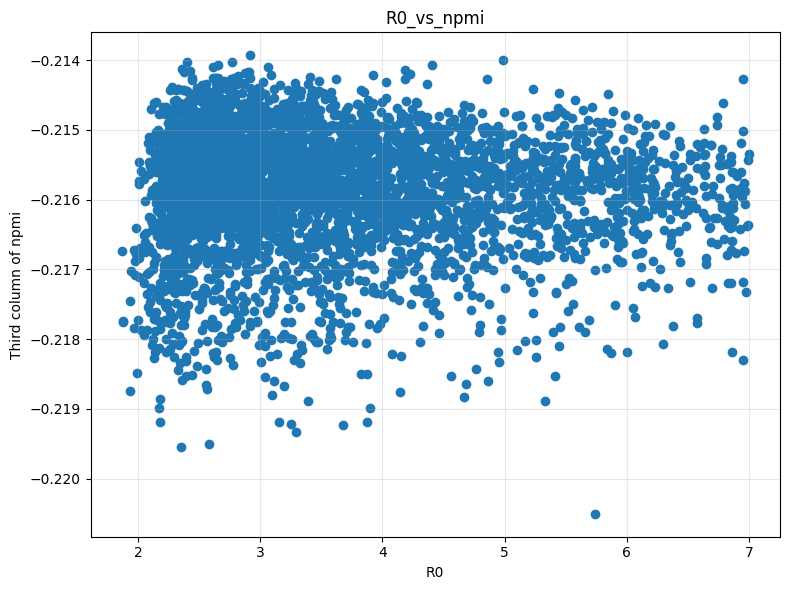

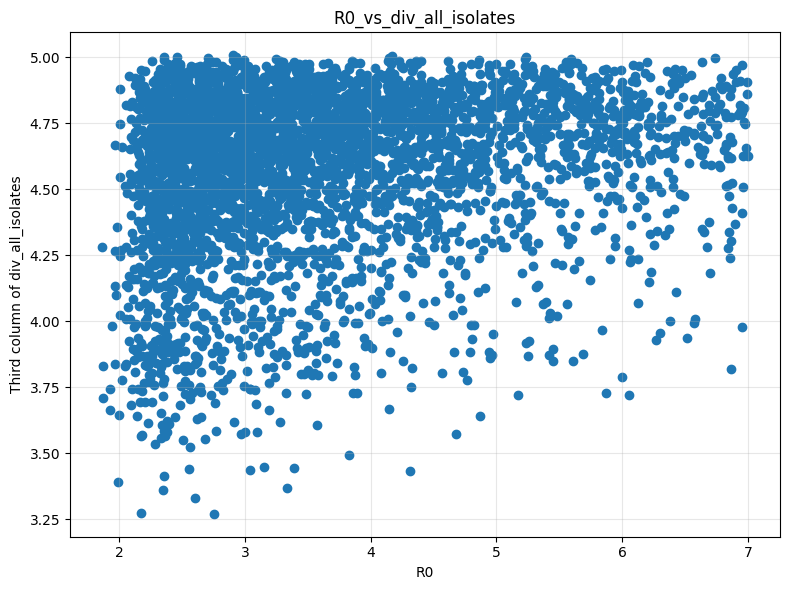

In [12]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    title='R0_vs_avg_prev',
    ss_name='avg_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p0/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    title='R0_vs_var_prev',
    ss_name='var_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p0/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    title='R0_vs_npmi',
    ss_name='npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p0/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    title='R0_vs_div_all_isolates',
    ss_name='div_all_isolates',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p0/'
)

In [13]:
# for euclidean, manhattan, chebyshev, minkowski, cosine
# 1. Euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 2. Manhattan distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="manhattan",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-manhattan",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 3. chebyshev
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="chebyshev",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-chebyshev",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 4. minkowski
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="minkowski",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-minkowski",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 5. cosine
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="cosine",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-cosine",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)


# for different wegihts in euclidean
# 1. (0.1, 0.1, 0.7, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight1",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 2. (0.7, 0.1, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.7, 0.1, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight2",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 3. (0.1, 0.7, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.7, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight3",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 4. (0.1, 0.1, 0.1, 0.7) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight4",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)


# 5. (0.05, 0.05, 0.7, 0.2) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight5",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)


Done. Results saved to '../../experimental_data/from_260312/dists_R04p0_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R04p0/R0_vs_sigma__Multiple_Percentileseuclidean.png
Done. Results saved to '../../experimental_data/from_260312/dists_R04p0_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R04p0/R0_vs_sigma__Multiple_Percentilesmanhattan.png
Done. Results saved to '../../experimental_data/from_260312/dists_R04p0_recal.csv'.
Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R04p0/R0_vs_sigma__Multiple_Percentileschebyshev.png
Done. Results saved to '../../experimental_data/from_260312/dist

Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R04p5/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)


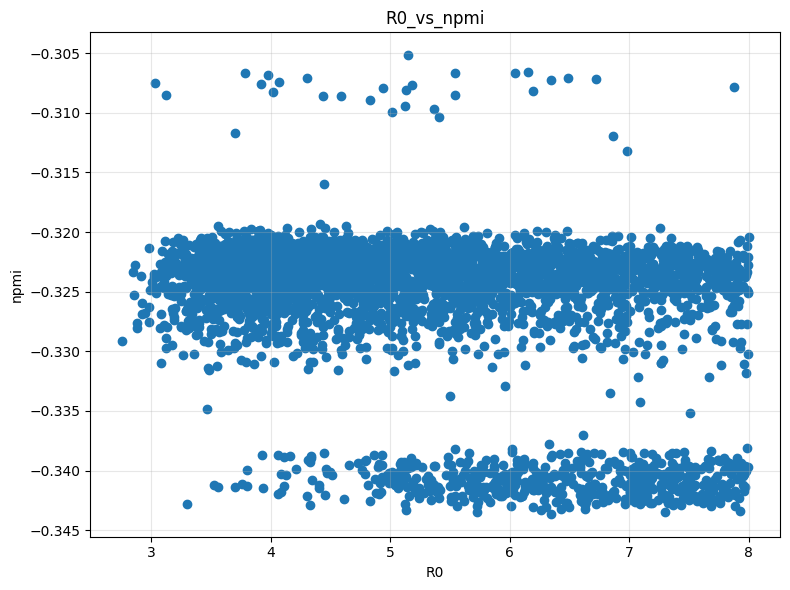

Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R04p5/R0_vs_npmi.png


In [7]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R04p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.5,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    title='R0_vs_avg_prev',
    ss_name='avg_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p5/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    title='R0_vs_var_prev',
    ss_name='var_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p5/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    title='R0_vs_npmi',
    ss_name='npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p5/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p5.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    title='R0_vs_div_all_isolates',
    ss_name='div_all_isolates',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p5/'
)

In [ ]:
# for euclidean, manhattan, chebyshev, minkowski, cosine
# 1. Euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p5.csv",
        standard_point=(114.73913043,  56.4714066, -0.32407692, 8.39831447),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)

# 2. Manhattan distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p5.csv",
        standard_point=(114.73913043,  56.4714066, -0.32407692, 8.39831447),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="manhattan",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-manhattan",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)

# 3. chebyshev
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p5.csv",
        standard_point=(114.73913043,  56.4714066, -0.32407692, 8.39831447),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="chebyshev",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-chebyshev",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)

# 4. minkowski
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p5.csv",
        standard_point=(114.73913043,  56.4714066, -0.32407692, 8.39831447),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="minkowski",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-minkowski",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)

# 5. cosine
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p5.csv",
        standard_point=(114.73913043,  56.4714066, -0.32407692, 8.39831447),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="cosine",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-cosine",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)


# for different wegihts in euclidean
# 1. (0.1, 0.1, 0.7, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p5.csv",
        standard_point=(114.73913043,  56.4714066, -0.32407692, 8.39831447),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight1",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)

# 2. (0.7, 0.1, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p5.csv",
        standard_point=(114.73913043,  56.4714066, -0.32407692, 8.39831447),
        weights=(0.7, 0.1, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight2",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)

# 3. (0.1, 0.7, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p5.csv",
        standard_point=(114.73913043,  56.4714066, -0.32407692, 8.39831447),
        weights=(0.1, 0.7, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight3",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)

# 4. (0.1, 0.1, 0.1, 0.7) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p5.csv",
        standard_point=(114.73913043,  56.4714066, -0.32407692, 8.39831447),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight4",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)


# 5. (0.05, 0.05, 0.7, 0.2) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p5.csv",
        standard_point=(114.73913043,  56.4714066, -0.32407692, 8.39831447),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p5_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p5_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p5.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p5.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight5",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p5/"
)


Loaded 4000 samples
selected: 4000 100
selected: 3200 80
selected: 2400 60
selected: 1600 40
selected: 800 20
selected: 400 10
Saved to ../../figures/from_260312/ppc/sigma0p6/R05p0/R0_vs_sigma__Multiple_Percentiles.png
Loaded A shape: (4000, 4)
Loaded B shape: (4000, 1)


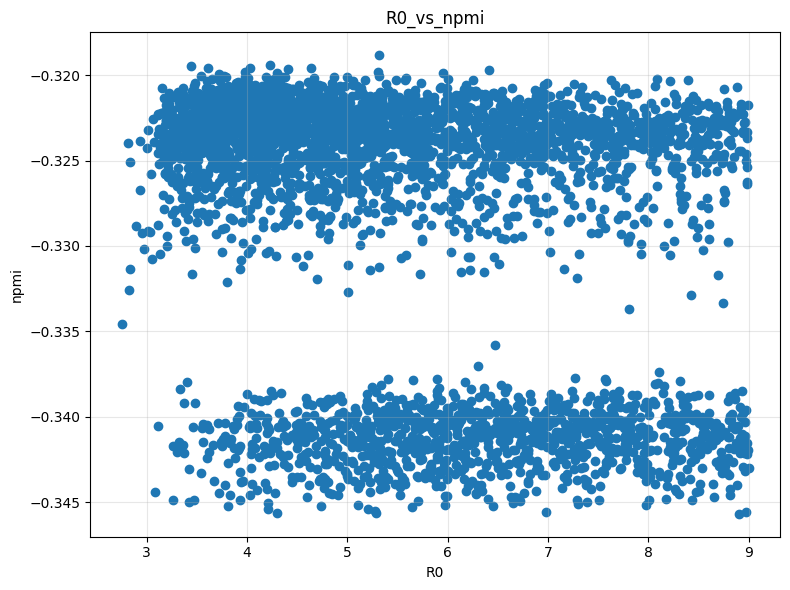

Figure saved to: ../../figures/from_260312/ppc/sigma0p6/R05p0/R0_vs_npmi.png


In [8]:
# Usage
plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_acc_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    title='R0_vs_avg_prev',
    ss_name='avg_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p0/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    title='R0_vs_var_prev',
    ss_name='var_prev',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p0/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    title='R0_vs_npmi',
    ss_name='npmi',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p0/'
)

plot_dots_from_two_files(
    file_ss='../../experimental_data/from_260312/ss_2params_R04p0.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    title='R0_vs_div_all_isolates',
    ss_name='div_all_isolates',
    save_dir='../../figures/from_260312/ppc/sigma0p6/R04p0/'
)

In [ ]:
# for euclidean, manhattan, chebyshev, minkowski, cosine
# 1. Euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 2. Manhattan distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="manhattan",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-manhattan",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 3. chebyshev
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="chebyshev",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-chebyshev",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 4. minkowski
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="minkowski",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-minkowski",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 5. cosine
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="cosine",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-cosine",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)


# for different wegihts in euclidean
# 1. (0.1, 0.1, 0.7, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.7, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight1",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 2. (0.7, 0.1, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.7, 0.1, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight2",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 3. (0.1, 0.7, 0.1, 0.1) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.7, 0.1, 0.1),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight3",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)

# 4. (0.1, 0.1, 0.1, 0.7) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight4",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)


# 5. (0.05, 0.05, 0.7, 0.2) in euclidean distance
result = analyze_distances(
        filepath="../../experimental_data/from_260312/ss_2params_R04p0.csv",
        standard_point=(87.73913043, 44.96384142, -0.21491576, 4.8991666),
        weights=(0.1, 0.1, 0.1, 0.7),            # ← will be normalized to sum=1
        metric="euclidean",
        p=3,
        output_path="../../experimental_data/from_260312/dists_R04p0_recal.csv"
    )

plot_dots_multiple_percentiles(
    file_dists='../../experimental_data/from_260312/dists_R04p0_recal.csv',
    file_R0='../../experimental_data/from_260312/R0_samps_2params_R04p0.csv',
    file_sigma='../../experimental_data/from_260312/sigma_samps_2params_R04p0.csv',
    percentiles=[100, 80, 60, 40, 20, 10],
    true_R0=4.0,
    true_sigma=0.6,
    title="R0 vs sigma - Multiple Percentiles-euclidean_weight5",
    save_path="../../figures/from_260312/ppc/sigma0p6/R04p0/"
)
